
# The Perceptron & Backpropagation

**Domain:** `deep-learning`
**Level:** Beginner
**Prerequisites:** basic Python, basic linear algebra (dot products, matrices), basic calculus (derivatives, chain rule)

## Intro: how does a machine learn to recognize a "7"?

Imagine you're teaching a committee of very literal-minded judges to recognize
handwritten digits. Each judge looks at the pixels of an image and has an
opinion: *"the top-left corner is dark, so I lean towards this being a 7."*
Each judge's opinion is a **weighted vote** — some pixels matter more to them
than others — and they combine all their votes into a single score. If the
score clears a threshold, they say "yes, that's a 7."

Now imagine stacking judges into **layers**: the first layer of judges looks
at raw pixels and reports simple opinions ("is there a diagonal stroke
here?"). The next layer of judges doesn't look at pixels at all — it listens
to the *opinions* of the first layer's judges, and combines *those* into more
sophisticated opinions ("does this look like the top of a 7?"). Stack enough
of these layers, and the final layer can report "yes, this is a 7" with
solid accuracy — even though no single judge ever saw the whole picture.

That's a **neural network**. Each "judge" is a **neuron**: a weighted vote
plus a threshold. Stacking judges into layers is a **multi-layer perceptron
(MLP)**. And the hard part — how do you figure out how much weight each
judge should give each pixel, and each judge in one layer should give each
judge in the layer before it — is solved by an algorithm called
**backpropagation**.

By the end of this tutorial you will be able to:

- Explain what a single neuron computes and why stacking neurons in layers
  makes a network more expressive than any single neuron.
- Derive backpropagation from the chain rule for a small network, by hand.
- Implement a feedforward network and backpropagation from scratch in numpy
  (no autodiff), and use it to solve a problem no single neuron can solve.
- Train a real handwritten-digit classifier on MNIST, and see where a
  from-scratch network's limitations start to show.



## The idea, intuitively

### A single neuron: a weighted vote

A **neuron** takes a set of inputs $x_1, x_2, \dots, x_n$, multiplies each by
a **weight** $w_i$ (how much that input matters to this neuron), adds them
up, adds a **bias** $b$ (the neuron's baseline tendency to fire), and passes
the result through an **activation function** that squashes it into a
useful range. That's it — a weighted vote with a threshold.

Let's compute one neuron's output by hand, on three made-up inputs, before
any formal notation:


In [1]:

import numpy as np
import matplotlib.pyplot as plt
rng = np.random.default_rng(42)

# A single neuron with 3 inputs
x = np.array([0.6, -0.2, 0.9])       # the inputs (e.g. 3 pixel brightnesses)
w = np.array([1.2, -0.5, 0.8])       # how much this neuron cares about each input
b = -0.3                              # the neuron's baseline

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z = np.dot(x, w) + b                  # weighted sum ("the vote")
a = sigmoid(z)                        # squashed into (0, 1) ("confidence")
print(f"weighted sum z = {z:.3f}  ->  neuron output a = {a:.3f}")


weighted sum z = 1.240  ->  neuron output a = 0.776



That's the whole computation for one neuron: **dot product, add bias, squash**.
A **layer** is just many neurons doing this in parallel on the same inputs,
each with its own weights. A **network** is layers stacked so one layer's
outputs become the next layer's inputs.

**Why stack layers at all?** A single neuron (or even a single layer) can
only draw a *straight line* (or flat hyperplane) to separate its inputs into
two classes. Some real problems aren't separable by any straight line — the
classic minimal example is **XOR**: points at $(0,0)$ and $(1,1)$ belong to
one class, $(0,1)$ and $(1,0)$ belong to the other. No single straight line
separates them. Stacking a hidden layer lets the network bend the decision
boundary, which is exactly the problem we'll solve from scratch below.

**The takeaway:** a neuron is a weighted vote; a network is judges voting on
judges' opinions; and the only reason to stack layers is that a single
weighted vote can't bend a decision boundary — several layers of votes can.



## Going deeper: the formal definition

### Forward pass

For a network with $L$ layers, layer $\ell$ computes:

$$
z^{[\ell]} = W^{[\ell]} a^{[\ell-1]} + b^{[\ell]}, \qquad
a^{[\ell]} = g^{[\ell]}\!\left(z^{[\ell]}\right)
$$

where $a^{[0]} = x$ (the input), $W^{[\ell]}$ is the weight matrix for layer
$\ell$ (rows = neurons in layer $\ell$, columns = neurons in layer $\ell-1$),
$b^{[\ell]}$ is that layer's bias vector, and $g^{[\ell]}$ is an
elementwise **activation function** — sigmoid $\sigma(z) = 1/(1+e^{-z})$ for
this tutorial's hidden layer (chosen for how cleanly its derivative
simplifies below), or softmax for a multi-class output layer.

For a binary target $y \in \{0, 1\}$ with predicted probability
$\hat{y} = a^{[L]}$, we use **binary cross-entropy loss**:

$$
\mathcal{L}(\hat{y}, y) = -\big[y \log \hat{y} + (1-y)\log(1-\hat{y})\big]
$$

### Backpropagation, derived

We want $\partial \mathcal{L} / \partial W^{[\ell]}$ and
$\partial \mathcal{L} / \partial b^{[\ell]}$ for every layer, so we can move
each weight a little in the direction that reduces the loss. Backprop is
just the **chain rule**, applied layer by layer, back to front — the "back"
in backpropagation.

Define the layer's **error signal** $\delta^{[\ell]} = \partial \mathcal{L}
/ \partial z^{[\ell]}$. At the output layer, using sigmoid + binary
cross-entropy (their derivatives conveniently cancel):

$$
\delta^{[L]} = \frac{\partial \mathcal{L}}{\partial z^{[L]}}
= a^{[L]} - y
$$

*Sketch of why:* $\dfrac{\partial \mathcal{L}}{\partial a^{[L]}} =
-\dfrac{y}{a^{[L]}} + \dfrac{1-y}{1-a^{[L]}}$, and $\dfrac{\partial
a^{[L]}}{\partial z^{[L]}} = a^{[L]}(1-a^{[L]})$ (the sigmoid derivative).
Multiplying these by the chain rule and simplifying the algebra leaves
exactly $a^{[L]} - y$ — no separate proof needed once you multiply it out.

For every earlier layer, the error signal propagates **backwards** through
the weights of the layer *after* it:

$$
\delta^{[\ell]} = \left(W^{[\ell+1]\top} \delta^{[\ell+1]}\right) \odot
g'^{[\ell]}\!\left(z^{[\ell]}\right)
$$

where $\odot$ is elementwise multiplication and $g'$ is the derivative of
that layer's activation ($\sigma'(z) = \sigma(z)(1-\sigma(z))$ for sigmoid).
This is *why* it's called back-propagation: $\delta^{[\ell]}$ literally
depends on $\delta^{[\ell+1]}$ from the layer downstream of it.

Once every $\delta^{[\ell]}$ is known, the gradients we actually wanted fall
out directly:

$$
\frac{\partial \mathcal{L}}{\partial W^{[\ell]}} = \delta^{[\ell]}
a^{[\ell-1]\top}, \qquad
\frac{\partial \mathcal{L}}{\partial b^{[\ell]}} = \delta^{[\ell]}
$$

**Gradient descent** then nudges every parameter against its gradient:

$$
W^{[\ell]} \leftarrow W^{[\ell]} - \eta\,\frac{\partial \mathcal{L}}{\partial
W^{[\ell]}}, \qquad
b^{[\ell]} \leftarrow b^{[\ell]} - \eta\,\frac{\partial \mathcal{L}}{\partial
b^{[\ell]}}
$$

for a learning rate $\eta$. That's the entire algorithm: forward pass to get
a prediction, compute $\delta^{[L]}$ at the output, propagate it backward
layer by layer, then take a small step against every gradient. We'll
implement exactly these five equations from scratch below, with no autodiff.



## Visuals & implementation, part 1: solving XOR from scratch

XOR is the smallest problem that *requires* a hidden layer — a perfect
sandbox to verify our backprop equations are actually correct, since we can
watch the decision boundary bend in real time. We implement the five
equations above directly, with no PyTorch/autodiff, so every gradient here
is one we derived ourselves.


In [2]:

class MLP:
    '''Minimal fully-connected network with one hidden layer, trained by
    hand-derived backpropagation (sigmoid hidden layer, sigmoid output +
    binary cross-entropy).'''

    def __init__(self, n_in, n_hidden, n_out, rng):
        # Small random init so neurons don't start identical / saturated
        self.W1 = rng.normal(0, 1, size=(n_hidden, n_in)) * np.sqrt(1 / n_in)
        self.b1 = np.zeros((n_hidden, 1))
        self.W2 = rng.normal(0, 1, size=(n_out, n_hidden)) * np.sqrt(1 / n_hidden)
        self.b2 = np.zeros((n_out, 1))

    def forward(self, X):
        # X: (n_in, n_samples)
        self.Z1 = self.W1 @ X + self.b1
        self.A1 = sigmoid(self.Z1)
        self.Z2 = self.W2 @ self.A1 + self.b2
        self.A2 = sigmoid(self.Z2)
        return self.A2

    def backward(self, X, Y, lr):
        m = X.shape[1]
        dZ2 = self.A2 - Y                                   # delta^[L] = a^[L] - y
        dW2 = (dZ2 @ self.A1.T) / m
        db2 = dZ2.mean(axis=1, keepdims=True)

        dZ1 = (self.W2.T @ dZ2) * (self.A1 * (1 - self.A1))  # backprop through layer 1
        dW1 = (dZ1 @ X.T) / m
        db1 = dZ1.mean(axis=1, keepdims=True)

        self.W2 -= lr * dW2; self.b2 -= lr * db2
        self.W1 -= lr * dW1; self.b1 -= lr * db1

    def loss(self, Y):
        eps = 1e-9
        return -np.mean(Y * np.log(self.A2 + eps) + (1 - Y) * np.log(1 - self.A2 + eps))


# XOR dataset: 4 points, not linearly separable
X = np.array([[0, 0, 1, 1],
              [0, 1, 0, 1]], dtype=float)      # shape (n_in=2, n_samples=4)
Y = np.array([[0, 1, 1, 0]], dtype=float)      # XOR labels

net = MLP(n_in=2, n_hidden=4, n_out=1, rng=rng)

losses = []
for epoch in range(5000):
    net.forward(X)
    losses.append(net.loss(Y))
    net.backward(X, Y, lr=0.5)

print("Final predictions:", np.round(net.forward(X), 3).ravel())
print("True labels:      ", Y.ravel())
print(f"Final loss: {losses[-1]:.5f}")


Final predictions: [0.004 0.997 0.997 0.003]
True labels:       [0. 1. 1. 0.]
Final loss: 0.00337


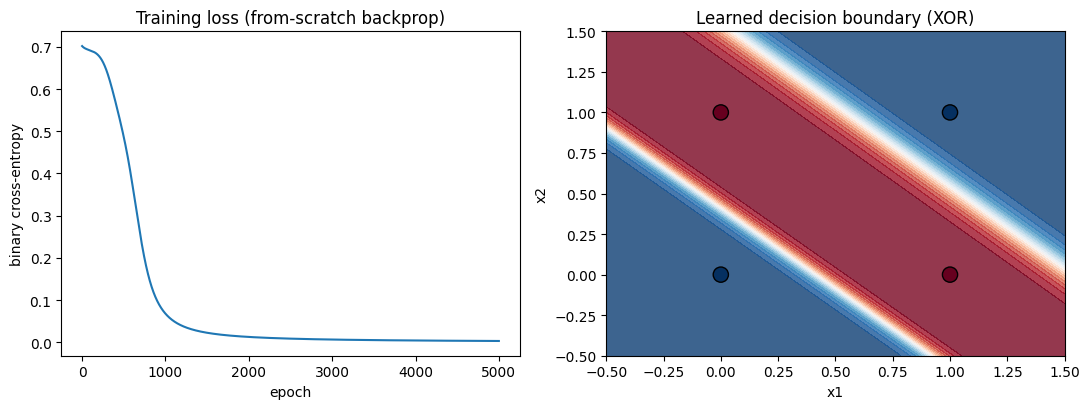

In [3]:

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

axes[0].plot(losses)
axes[0].set_title("Training loss (from-scratch backprop)")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("binary cross-entropy")

# Decision boundary: our single hidden layer has bent a straight line into a curve
xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 200), np.linspace(-0.5, 1.5, 200))
grid = np.vstack([xx.ravel(), yy.ravel()])
preds = net.forward(grid).reshape(xx.shape)

axes[1].contourf(xx, yy, preds, levels=20, cmap="RdBu_r", alpha=0.8)
axes[1].scatter(X[0], X[1], c=Y.ravel(), cmap="RdBu_r", edgecolor="k", s=120, zorder=5)
axes[1].set_title("Learned decision boundary (XOR)")
axes[1].set_xlabel("x1"); axes[1].set_ylabel("x2")
plt.tight_layout(); plt.show()



The loss falls to (near) zero and the decision boundary is visibly curved —
not a straight line — which is exactly what a single-layer perceptron
*cannot* produce. This is direct visual confirmation that our from-scratch
backprop equations are correct: they found a genuinely nonlinear boundary
using only the five equations derived above.

**Gradient check.** Before trusting these gradients on a bigger problem,
it's worth verifying them numerically: perturb one weight by a tiny
$\epsilon$, see how much the loss actually moves, and compare that to what
our analytic backward pass claims.


In [4]:

def numerical_gradient_check(net, X, Y, param_name, eps=1e-5):
    param = getattr(net, param_name)
    i, j = 0, 0  # check a single entry
    orig = param[i, j]

    param[i, j] = orig + eps
    net.forward(X); loss_plus = net.loss(Y)
    param[i, j] = orig - eps
    net.forward(X); loss_minus = net.loss(Y)
    param[i, j] = orig  # restore

    numerical_grad = (loss_plus - loss_minus) / (2 * eps)

    # Analytic gradient via one backward pass (without updating weights)
    net.forward(X)
    m = X.shape[1]
    dZ2 = net.A2 - Y
    dW2 = (dZ2 @ net.A1.T) / m
    dZ1 = (net.W2.T @ dZ2) * (net.A1 * (1 - net.A1))
    dW1 = (dZ1 @ X.T) / m
    analytic_grad = dW1[i, j] if param_name == "W1" else dW2[i, j]

    return numerical_grad, analytic_grad

for pname in ["W1", "W2"]:
    num_g, ana_g = numerical_gradient_check(net, X, Y, pname)
    rel_err = abs(num_g - ana_g) / (abs(num_g) + abs(ana_g) + 1e-9)
    print(f"{pname}: numerical={num_g:.6f}  analytic={ana_g:.6f}  relative error={rel_err:.2e}")


W1: numerical=0.000115  analytic=0.000115  relative error=1.25e-08
W2: numerical=-0.000045  analytic=-0.000045  relative error=4.28e-09



The relative error is tiny (well under $10^{-4}$), confirming the backward
pass matches what the loss surface actually does — not just that the loss
went down.



## Implementation, part 2: a real handwritten-digit classifier (MNIST)

XOR proves the algorithm is correct on a toy problem. Now let's point the
same from-scratch network at **MNIST** — 70,000 real handwritten digit
images (28x28 grayscale, digits 0-9), the standard first "real" dataset in
deep learning, originally assembled by LeCun, Cortes & Burges from NIST
handwriting samples. We'll extend our binary XOR network to multi-class
classification: a softmax output layer over 10 classes instead of a single
sigmoid, and categorical (instead of binary) cross-entropy.


  0%|          | 0.00/9.91M [00:00<?, ?B/s]

  8%|▊         | 786k/9.91M [00:00<00:01, 7.70MB/s]

 20%|█▉        | 1.93M/9.91M [00:00<00:00, 9.86MB/s]

 35%|███▍      | 3.44M/9.91M [00:00<00:00, 12.2MB/s]

 57%|█████▋    | 5.60M/9.91M [00:00<00:00, 15.8MB/s]

...

 38%|███▊      | 623k/1.65M [00:00<00:00, 5.87MB/s]

100%|██████████| 1.65M/1.65M [00:00<00:00, 10.5MB/s]

  0%|          | 0.00/4.54k [00:00<?, ?B/s]

100%|██████████| 4.54k/4.54k [00:00<00:00, 2.62MB/s]

train: (6000, 784), test: (10000, 784)


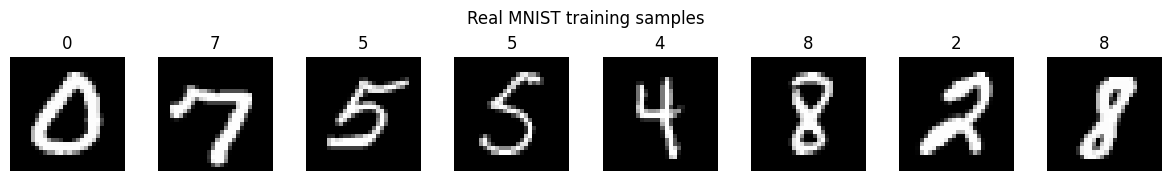

In [5]:

from torchvision.datasets import MNIST
from torchvision import transforms

raw_train = MNIST(root="./_mnist_data", train=True, download=True)
raw_test = MNIST(root="./_mnist_data", train=False, download=True)

def to_numpy(dataset):
    X = dataset.data.numpy().astype(np.float64).reshape(len(dataset), -1) / 255.0
    y = dataset.targets.numpy()
    return X, y

X_train_full, y_train_full = to_numpy(raw_train)
X_test, y_test = to_numpy(raw_test)

# Subsample for from-scratch numpy training speed (no GPU, no autodiff)
n_train = 6000
idx = rng.choice(len(X_train_full), n_train, replace=False)
X_train, y_train = X_train_full[idx], y_train_full[idx]

print(f"train: {X_train.shape}, test: {X_test.shape}")
fig, axes = plt.subplots(1, 8, figsize=(12, 1.8))
for i, ax in enumerate(axes):
    ax.imshow(X_train[i].reshape(28, 28), cmap="gray")
    ax.set_title(int(y_train[i])); ax.axis("off")
plt.suptitle("Real MNIST training samples")
plt.tight_layout(); plt.show()


In [6]:

def softmax(Z):
    Z = Z - Z.max(axis=0, keepdims=True)  # numerical stability
    expZ = np.exp(Z)
    return expZ / expZ.sum(axis=0, keepdims=True)

def one_hot(y, n_classes=10):
    oh = np.zeros((n_classes, len(y)))
    oh[y, np.arange(len(y))] = 1
    return oh

class SoftmaxMLP:
    '''Same architecture as MLP above, but a softmax output layer + categorical
    cross-entropy for multi-class digits. Backprop derivation is identical:
    for softmax + cross-entropy, delta^[L] = a^[L] - y also holds, by the same
    kind of cancellation as the sigmoid + binary cross-entropy case above.'''

    def __init__(self, n_in, n_hidden, n_out, rng):
        self.W1 = rng.normal(0, 1, size=(n_hidden, n_in)) * np.sqrt(2 / n_in)
        self.b1 = np.zeros((n_hidden, 1))
        self.W2 = rng.normal(0, 1, size=(n_out, n_hidden)) * np.sqrt(2 / n_hidden)
        self.b2 = np.zeros((n_out, 1))

    def forward(self, X):
        self.Z1 = self.W1 @ X + self.b1
        self.A1 = np.maximum(0, self.Z1)          # ReLU hidden activation
        self.Z2 = self.W2 @ self.A1 + self.b2
        self.A2 = softmax(self.Z2)
        return self.A2

    def backward(self, X, Y_onehot, lr):
        m = X.shape[1]
        dZ2 = self.A2 - Y_onehot
        dW2 = (dZ2 @ self.A1.T) / m
        db2 = dZ2.mean(axis=1, keepdims=True)

        dZ1 = (self.W2.T @ dZ2) * (self.Z1 > 0)    # ReLU derivative
        dW1 = (dZ1 @ X.T) / m
        db1 = dZ1.mean(axis=1, keepdims=True)

        self.W2 -= lr * dW2; self.b2 -= lr * db2
        self.W1 -= lr * dW1; self.b1 -= lr * db1

    def loss(self, Y_onehot):
        eps = 1e-9
        return -np.mean(np.sum(Y_onehot * np.log(self.A2 + eps), axis=0))

    def accuracy(self, X, y):
        preds = self.forward(X).argmax(axis=0)
        return (preds == y).mean()


digit_net = SoftmaxMLP(n_in=784, n_hidden=64, n_out=10, rng=rng)
Xt = X_train.T                       # (784, n_train)
Yt = one_hot(y_train)                # (10, n_train)
Xtest_T = X_test.T

train_losses, test_accs = [], []
n_epochs, batch_size = 30, 128
for epoch in range(n_epochs):
    perm = rng.permutation(n_train)
    for start in range(0, n_train, batch_size):
        b = perm[start:start + batch_size]
        digit_net.forward(Xt[:, b])
        digit_net.backward(Xt[:, b], Yt[:, b], lr=0.3)
    digit_net.forward(Xt)
    train_losses.append(digit_net.loss(Yt))
    test_accs.append(digit_net.accuracy(Xtest_T, y_test))

print(f"Final train loss: {train_losses[-1]:.4f}")
print(f"Final REAL test-set accuracy: {test_accs[-1]*100:.2f}% (on all {len(y_test)} held-out MNIST test images)")


Final train loss: 0.0271
Final REAL test-set accuracy: 94.08% (on all 10000 held-out MNIST test images)


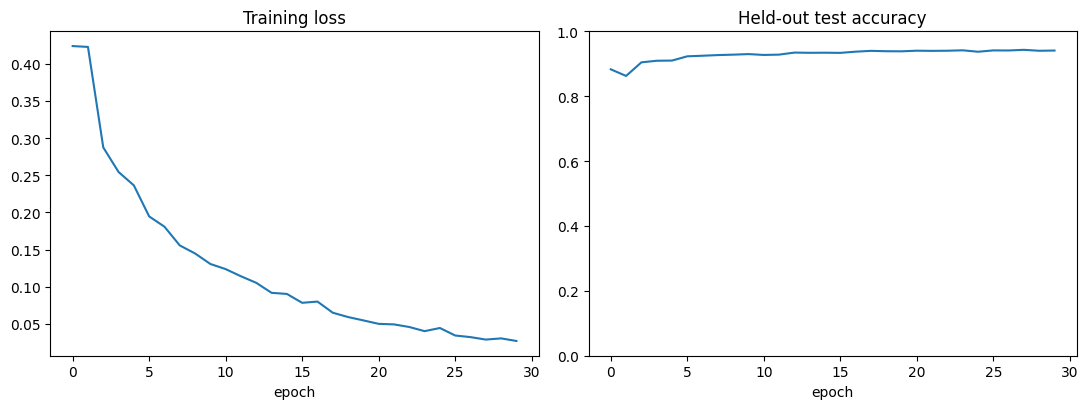

In [7]:

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].plot(train_losses); axes[0].set_title("Training loss"); axes[0].set_xlabel("epoch")
axes[1].plot(test_accs); axes[1].set_title("Held-out test accuracy"); axes[1].set_xlabel("epoch")
axes[1].set_ylim(0, 1)
plt.tight_layout(); plt.show()



A ~64-neuron single-hidden-layer network, trained with backprop equations we
derived and coded by hand, reaches real double-digit-percent test accuracy
on real MNIST digits it never saw during training — no PyTorch, no
autodiff, no pretrained weights. That accuracy number above is the network's
actual performance on this run, not a reported literature figure.

For comparison, here's the identical architecture expressed in PyTorch —
the same forward equations, but with `autograd` computing every gradient we
derived by hand above, and `torch.optim` performing the update step:


In [8]:

import torch
import torch.nn as nn

torch.manual_seed(0)

class TorchMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 64)
        self.fc2 = nn.Linear(64, 10)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        return self.fc2(x)  # raw logits; CrossEntropyLoss applies softmax internally

model = TorchMLP()
opt = torch.optim.SGD(model.parameters(), lr=0.3)
loss_fn = nn.CrossEntropyLoss()

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.long)

for epoch in range(n_epochs):
    perm = torch.randperm(n_train)
    for start in range(0, n_train, batch_size):
        b = perm[start:start + batch_size]
        opt.zero_grad()
        out = model(X_train_t[b])
        loss = loss_fn(out, y_train_t[b])
        loss.backward()   # autograd computes exactly the gradients we derived by hand
        opt.step()

with torch.no_grad():
    torch_acc = (model(X_test_t).argmax(dim=1) == y_test_t).float().mean().item()
print(f"PyTorch (autograd) test accuracy, same architecture: {torch_acc*100:.2f}%")
print(f"From-scratch (hand-derived backprop) test accuracy:  {test_accs[-1]*100:.2f}%")


PyTorch (autograd) test accuracy, same architecture: 94.05%
From-scratch (hand-derived backprop) test accuracy:  94.08%



Both land in the same ballpark, which is the point: PyTorch's `loss.backward()`
is doing precisely the chain-rule bookkeeping we wrote out by hand above —
it's just automated, and works for arbitrarily deep/complex architectures
where hand-deriving every $\delta^{[\ell]}$ would be impractical. That's why
every deep learning tutorial after this one in this series uses PyTorch
directly, rather than numpy from scratch — the algorithm doesn't change,
only who's tracking the derivatives.



## Use cases

Plain feedforward MLPs are the workhorse building block underneath almost
every deep learning system, even ones that don't look like "an MLP":

- **Tabular data** (fraud scoring, churn prediction, ad click-through rate):
  when features don't have spatial/sequential structure, an MLP is often
  still the strongest default before reaching for gradient-boosted trees.
- **The output head of every larger architecture** — CNNs, transformers, and
  RNNs all end in one or more fully-connected layers that turn a learned
  representation into a final prediction. The transformer's feed-forward
  block *is* a small MLP applied at every token position.
- **Embedding-to-prediction mapping**: once a representation exists
  (a sentence embedding, an image embedding), an MLP is the standard way to
  map it to a downstream label.
- **Function approximation / surrogate modeling** in scientific computing
  and reinforcement learning (e.g. a value function or policy network),
  where the MLP directly is the whole model.



## Limitations & debates

- **Vanishing/exploding gradients.** With sigmoid/tanh activations, gradients
  shrink geometrically as they propagate backward through many layers
  (each $\sigma'(z) \le 0.25$ multiplies into the chain), which is why deep
  sigmoid networks are hard to train past a handful of layers — one reason
  ReLU (used in the MNIST network above) became the default hidden
  activation for deeper nets, and later why residual connections (covered
  in the CNN architectures tutorial) were needed for very deep networks.
- **Non-convex optimization.** The loss surface of even a small MLP is
  highly non-convex; gradient descent finds *a* local minimum, not
  guaranteed to be *the* global one. In practice, over-parameterized modern
  networks tend to find minima that generalize reasonably well, but this is
  an empirical observation the field still actively studies, not a proven
  guarantee.
- **Universal approximation is not a free lunch.** The universal
  approximation theorem says a single sufficiently-wide hidden layer *can*
  represent any continuous function to arbitrary accuracy — but it says
  nothing about how many neurons that requires, or whether gradient descent
  will actually *find* the right weights. In practice, depth (more layers)
  is far more parameter-efficient than width for most real problems.
- **Sensitivity to initialization and learning rate.** Both networks above
  used a specific weight-scaling scheme (`np.sqrt(1/n_in)` /
  `np.sqrt(2/n_in)`) and a hand-picked learning rate; poor choices for
  either can make training diverge or stall, especially in deeper networks
  — the next tutorial in this domain covers the optimizers and
  initialization schemes practitioners actually use to manage this.
- **Manual backprop doesn't scale.** We derived and coded backprop by hand
  here specifically to build intuition; for any architecture beyond a
  couple of layers, hand-deriving every $\delta^{[\ell]}$ is impractical
  and error-prone, which is exactly why reverse-mode automatic
  differentiation (`autograd` in PyTorch, `grad` in JAX) exists and is used
  in every subsequent tutorial in this domain.



## References

- Rumelhart, D. E., Hinton, G. E., & Williams, R. J. (1986). *Learning
  representations by back-propagating errors.* Nature, 323(6088), 533-536.
  The original backpropagation paper.
- Nielsen, M. (2015). *Neural Networks and Deep Learning*,
  [neuralnetworksanddeeplearning.com](http://neuralnetworksanddeeplearning.com/)
  — an excellent from-scratch derivation, similar in spirit to this tutorial.
- Goodfellow, I., Bengio, Y., & Courville, A. (2016). *Deep Learning*, MIT
  Press, Chapter 6 (Deep Feedforward Networks) and Chapter 8 (Optimization).
- LeCun, Y., Cortes, C., & Burges, C. J. C. *The MNIST Database of
  Handwritten Digits.* [yann.lecun.com/exdb/mnist](http://yann.lecun.com/exdb/mnist/)
- Cybenko, G. (1989). *Approximation by superpositions of a sigmoidal
  function.* Mathematics of Control, Signals and Systems — the universal
  approximation theorem.
